<a href="https://colab.research.google.com/github/Farah-Balbaa/Python-Projects/blob/main/SuperStore2019/Superstore_MiniProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA & Data Cleaning - *Sample Superstore 2019 Orders Dataset*
> **DEPI** | Mini-Project (1)




## Introduction

This notebook documents the exploratory data analysis (EDA) and data-cleaning process applied to the **Sample Superstore 2019 Orders** dataset. The dataset contains order-level retail transaction records, including customer, product, shipping, sales, and profit information.

The objective is to:
- Understand the structure and quality of the raw data
- Identify and fix data-quality issues (missing values, duplicates, wrong data types)
- Explore relationships between sales, profit, discount, and other business dimensions
- Produce a clean, analysis-ready dataset

## ⏩ 1. Importing libraries & Inspecing the data

In [1]:
import pandas as pd
import numpy as npa
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/Sample - Superstore 2019(Orders).csv', encoding='latin1')

Identify the available columns

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2018-152156,11/8/2018,11/11/2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2.0,CA-2018-152156,11/8/2018,11/11/2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3.0,CA-2018-138688,6/12/2018,6/16/2018,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4.0,US-2017-108966,10/11/2017,10/18/2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5.0,US-2017-108966,10/11/2017,10/18/2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


Next, check column data types and null counts.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   float64
 1   Order ID        9994 non-null   object 
 2   Order Date      9994 non-null   object 
 3   Ship Date       9994 non-null   object 
 4   Ship Mode       9994 non-null   object 
 5   Customer ID     9994 non-null   object 
 6   Customer Name   9994 non-null   object 
 7   Segment         9994 non-null   object 
 8   Country/Region  9994 non-null   object 
 9   City            9994 non-null   object 
 10  State           9994 non-null   object 
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   object 
 13  Product ID      9994 non-null   object 
 14  Category        9994 non-null   object 
 15  Sub-Category    9994 non-null   object 
 16  Product Name    9994 non-null   object 
 17  Sales           9994 non-null   f

Here, we can observe **two** rows containing **null** values. Since these rows are common and do not provide meaningful information, we will **drop** them from the dataset.

The `Row ID` column does not provide any meaningful information about the customer, as it only represents a **sequential identifier**. Therefore, we can safely drop it from the dataset and reset the index using Python’s indexing functionality after completing the data-cleaning process.

11 rows are still missing in `Postal Code`.
Our plan to see if these rows have the same common values or belong to the same city/state or there is another pattern we're going to figure it out.

## ⏩ 2. Data Processing

In [5]:
df = df.dropna(subset=['Row ID'])
df.drop(columns=['Row ID'], inplace=True)

In [6]:
df.isna().sum()[df.isna().sum() > 0]

,0
Postal Code,11


In [7]:
missing_pc = df[df['Postal Code'].isna()][['City', 'State']].drop_duplicates()
print(missing_pc)

            City    State
2234  Burlington  Vermont


All the remaining missing postal codes belong to **Burlington, Vermont**, whose ZIP code is publicly known to be **05401**. Rather than deleting these 11 valid sales records, we fill in the correct value.

In [8]:
n_before = df['Postal Code'].isna().sum()
df.loc[
    (df['City'] == 'Burlington') & (df['State'] == 'Vermont') & (df['Postal Code'].isna()),
    'Postal Code'] = 5401

n_after = df['Postal Code'].isna().sum()
print(f"Missing postal codes before fix: {n_before}")
print(f"Missing postal codes after fix: {n_after}")

Missing postal codes before fix: 11
Missing postal codes after fix: 0


Fix the data types and formatting

In [9]:
df['Postal Code'] = df['Postal Code'].astype(int).astype(str).str.zfill(5)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y', errors='coerce')
df['Quantity'] = df['Quantity'].astype(int)
df[['Postal Code','Order Date','Ship Date','Quantity']].dtypes

,0
Postal Code,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Quantity,int64


In [10]:
df['year'] = pd.to_datetime(df['Order Date']).dt.year
df['month'] = pd.to_datetime(df['Order Date']).dt.month.astype(str)
df['month name'] = pd.to_datetime(df['Order Date']).dt.month_name()
df['day'] = pd.to_datetime(df['Order Date']).dt.day
df['quarter'] = pd.to_datetime(df['Order Date']).dt.quarter

In [11]:
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

after that, check duplicates


In [12]:
print(f"Number of duplicate rows found: {df.duplicated().sum()}")

Number of duplicate rows found: 1


In [13]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before}")
print(f"Rows after removing duplicates: {after}")
print(f"Duplicate rows removed: {before - after}")

Rows before: 9994
Rows after removing duplicates: 9993
Duplicate rows removed: 1


In [14]:
print(f"Total remaining missing values in the cleaned dataset:\n{df.isna().sum()}")

Total remaining missing values in the cleaned dataset:
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
Country/Region       0
City                 0
State                0
Postal Code          0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Quantity             0
Discount             0
Profit               0
year                 0
month                0
month name           0
day                  0
quarter              0
Shipping Duration    0
dtype: int64


As a final step, we check if there is logical mistakes in `Quantity`, `Discount` , `Ship Date` and `Order Date`

In [15]:
neg_sales = (df['Sales'] < 0).sum()
neg_qty = (df['Quantity'] < 0).sum()
bad_discount = ((df['Discount'] < 0) | (df['Discount'] > 1)).sum()
ship_before_order = (df['Ship Date'] < df['Order Date']).sum()

print(f"Negative Sales values: {neg_sales}")
print(f"Negative Quantity values: {neg_qty}")
print(f"Discount outside [0,1]: {bad_discount}")
print(f"Ship Date earlier than Order Date: {ship_before_order}")

Negative Sales values: 0
Negative Quantity values: 0
Discount outside [0,1]: 0
Ship Date earlier than Order Date: 0


As a final touch, check for extra spaces, lowercase our data and rename columns.

In [16]:
df.columns = df.columns.str.lower().str.strip().str.replace(r'\s+', '_', regex=True).str.replace("-", "_")
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df[col] = df[col].str.lower().str.strip().str.replace('_', ' ')

In [17]:
df = df.rename(columns={'country/region': 'country'})

## ⏩ 3. Cleaned Version

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           9993 non-null   object        
 1   order_date         9993 non-null   datetime64[ns]
 2   ship_date          9993 non-null   datetime64[ns]
 3   ship_mode          9993 non-null   object        
 4   customer_id        9993 non-null   object        
 5   customer_name      9993 non-null   object        
 6   segment            9993 non-null   object        
 7   country            9993 non-null   object        
 8   city               9993 non-null   object        
 9   state              9993 non-null   object        
 10  postal_code        9993 non-null   object        
 11  region             9993 non-null   object        
 12  product_id         9993 non-null   object        
 13  category           9993 non-null   object        
 14  sub_category 

In [19]:
df.reset_index(drop=True, inplace=True)

In [20]:
from google.colab import files
df.to_csv('superstore_cleanedVersion.csv', index=False)

In [21]:
test_df = pd.read_csv('superstore_cleanedVersion.csv')
print(test_df.head())

         order_id  order_date   ship_date       ship_mode customer_id  \
0  ca-2018-152156  2018-11-08  2018-11-11    second class    cg-12520   
1  ca-2018-152156  2018-11-08  2018-11-11    second class    cg-12520   
2  ca-2018-138688  2018-06-12  2018-06-16    second class    dv-13045   
3  us-2017-108966  2017-10-11  2017-10-18  standard class    so-20335   
4  us-2017-108966  2017-10-11  2017-10-18  standard class    so-20335   

     customer_name    segment        country             city       state  \
0      claire gute   consumer  united states        henderson    kentucky   
1      claire gute   consumer  united states        henderson    kentucky   
2  darrin van huff  corporate  united states      los angeles  california   
3   sean o'donnell   consumer  united states  fort lauderdale     florida   
4   sean o'donnell   consumer  united states  fort lauderdale     florida   

   ...     sales quantity discount    profit  year month  month_name  day  \
0  ...  261.9600     

In [22]:
files.download('superstore_cleanedVersion.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ⭐**KPIs**

In [23]:
Total_Sales = df['sales'].sum().round(2)
Applied_Discount_Count = (df["discount"] > 0).sum()
Max_Discount = df["discount"].max()
Avg_shipping_duration = df["shipping_duration"].mean().round()
top_city = df.groupby("city")["order_id"].nunique().idxmax()
top_city_orders = df.groupby("city")["order_id"].nunique().max()

print(f"Total Sales:{Total_Sales:,}")
print(f"Total Number of Applied Discount:{Applied_Discount_Count:,}")
print(f"Max Discount:{Max_Discount*100}")
print(f"Avgerage Shipping Duration:{Avg_shipping_duration}")
print(f"Top City:{top_city}")
print(f"Top City Orders:{top_city_orders:,}")

Total Sales:2,296,919.49
Total Number of Applied Discount:5,195
Max Discount:80.0
Avgerage Shipping Duration:4.0
Top City:new york city
Top City Orders:450


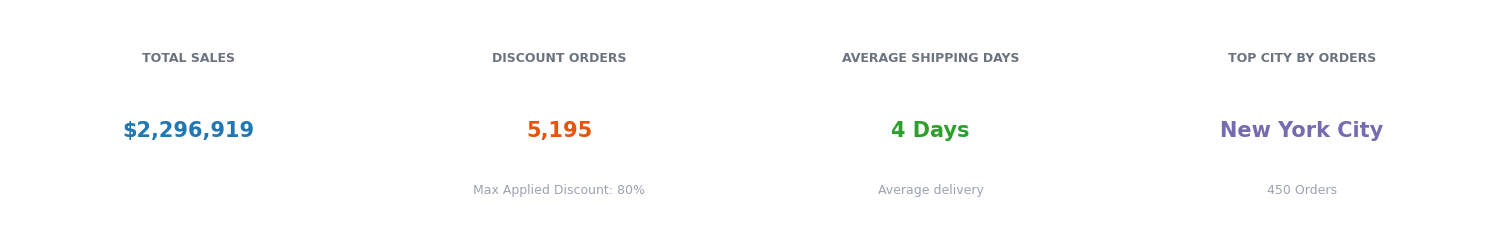

In [24]:
kpi_data = [
    {"title": "TOTAL SALES", "value": f"${Total_Sales:,.0f}","sub": "" ,"color": "#1f77b4"},
    {"title": "DISCOUNT ORDERS", "value": f"{Applied_Discount_Count:,}", "sub": f"Max Applied Discount: {Max_Discount*100:.0f}%", "color": "#e6550d"},
    {"title": "AVERAGE SHIPPING DAYS", "value": f"{int(Avg_shipping_duration)} Days", "sub": "Average delivery", "color": "#2ca02c"},
    {"title": "TOP CITY BY ORDERS", "value": f"{top_city.title()}", "sub": f"{top_city_orders:,} Orders", "color": "#756bb1"}
]

fig, axes = plt.subplots(1, 4, figsize=(15, 2.5))

for ax, kpi in zip(axes, kpi_data):
    ax.axis("off")
    card_box = dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#e5e7eb", linewidth=1.5)
    ax.text(0.5, 0.5, "", bbox=card_box, transform=ax.transAxes, zorder=-1)
    ax.text(0.5, 0.78, kpi["title"], ha="center", va="center", fontsize=9, color="#6b7280", weight="bold")
    ax.text(0.5, 0.45, kpi["value"], ha="center", va="center", fontsize=15, color=kpi["color"], weight="bold")
    ax.text(0.5, 0.18, kpi["sub"], ha="center", va="center", fontsize=9, color="#9ca3af")

plt.tight_layout()
plt.show()


## ⭐ **VISUALS**

🔢 **Total Sales By Category** | Column Chart

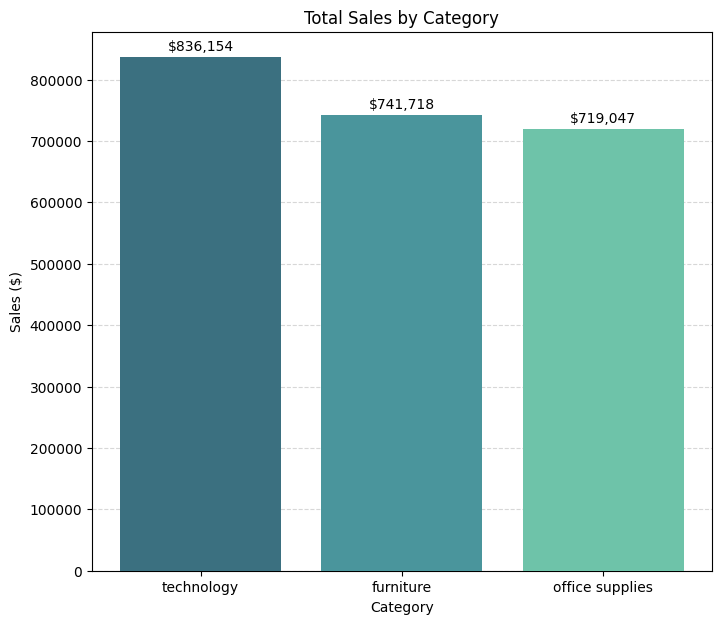

In [25]:
cat_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False) #"ascending=false" in order to be from the higher one to the lower

plt.figure(figsize=(8, 7))
bars = plt.bar(cat_sales.index, cat_sales.values, color=['#3b7080', '#4a959c', '#6ec3a9'], zorder=3)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.bar_label(bars, fmt="${:,.0f}", padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.show()

🔢 **Total Profit by Region** | Bar Chart

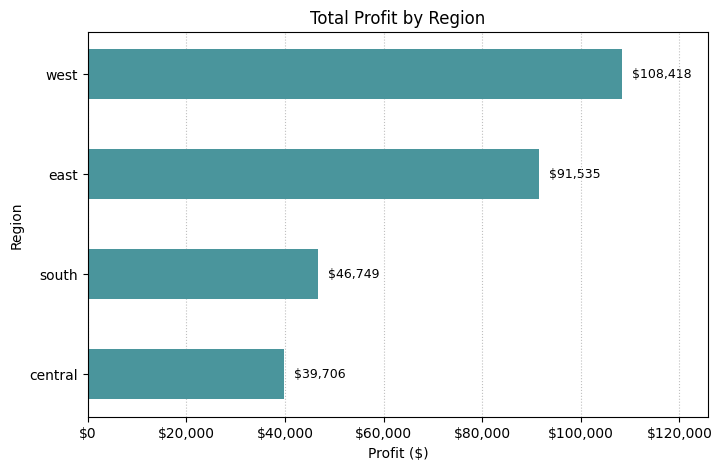

In [26]:
reg_profit = df.groupby("region")["profit"].sum().sort_values()
bar_colors = ["#d62728" if v < 0 else "#4a959c" for v in reg_profit.values]

plt.figure(figsize=(8, 5))

bars = plt.barh(
    reg_profit.index,
    reg_profit.values,
    color=bar_colors,
    height=0.5,
    zorder=2
)

plt.title("Total Profit by Region")
plt.xlabel("Profit ($)")
plt.ylabel("Region")

ticks, _ = plt.xticks()
plt.xticks(ticks, [f"${x:,.0f}" for x in ticks])

plt.margins(x=0.16)
plt.grid(axis="x", linestyle=":", alpha=0.8, zorder=0)

for b in bars:
    w = b.get_width()
    plt.text(
        w + (2000 if w >= 0 else -2000),
        b.get_y() + b.get_height() / 2,
        f"${w:,.0f}",
        va="center",
        ha="left" if w >= 0 else "right",
        fontsize=9,
        zorder=0
    )

plt.show()

🔢 **Monthly Sales Trend (2016-2019)** | Line Chart

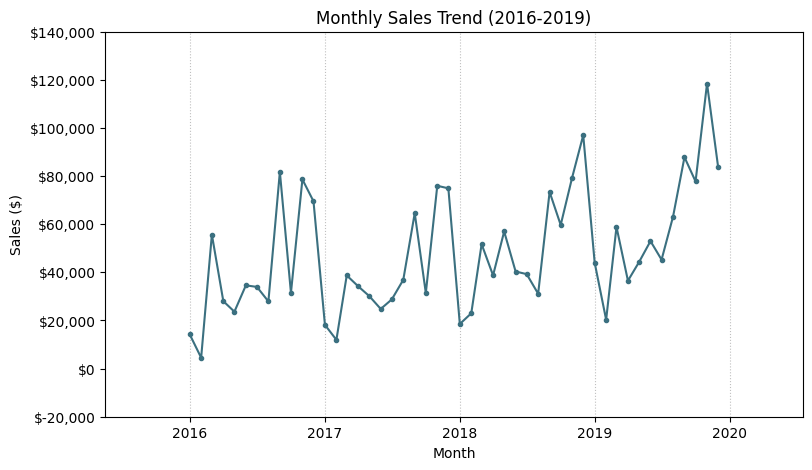

In [27]:
monthly = df.groupby([df["order_date"].dt.to_period("M")])["sales"].sum()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(9, 5))
plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    markersize=3,
    linewidth=1.5,
    color="#3b7080",
)

plt.margins(x=0.16)
plt.grid(axis="x", linestyle=":", alpha=0.8, zorder=0)

plt.title("Monthly Sales Trend (2016-2019)")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

yticks, _ = plt.yticks()
plt.yticks(yticks, [f"${int(y):,}" for y in yticks])

plt.show()

🔢 **Quarterly Sales Trend (2016-2019)** | Column Chart

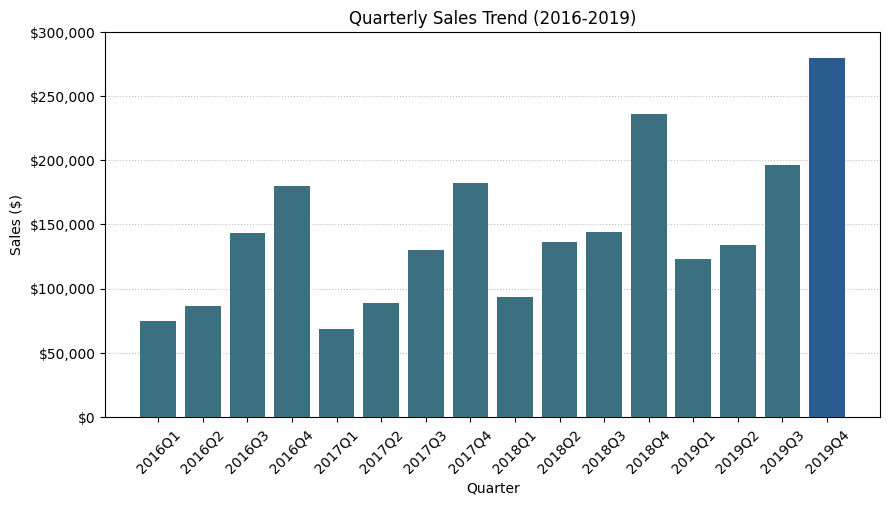

In [28]:
quarterly_sales = df.groupby(df["order_date"].dt.to_period("Q"))["sales"].sum()

max_val = quarterly_sales.max()
colors = ['#2b5c8f' if val == max_val else '#3b7080' for val in quarterly_sales.values]

plt.figure(figsize=(10, 5))
plt.bar(quarterly_sales.index.astype(str), quarterly_sales.values, color=colors, zorder=3)

plt.title("Quarterly Sales Trend (2016-2019)")
plt.xlabel("Quarter")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle=":", alpha=0.8, zorder=0)

yticks, _ = plt.yticks()
plt.yticks(yticks, [f"${int(y):,}" for y in yticks])

plt.show()

🔢 **Total Sales by Customer Segment** | Pie Chart

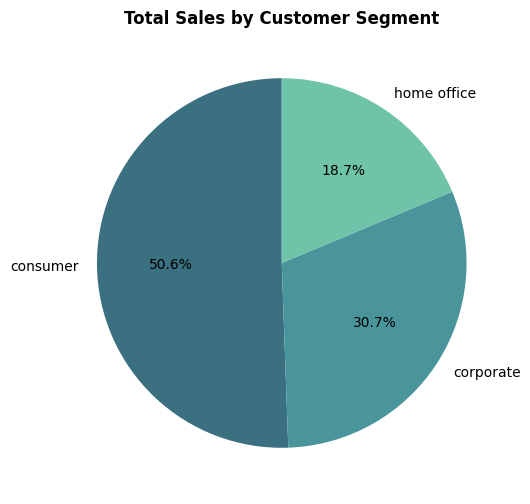

In [29]:
seg_counts = df.groupby("segment", observed=True)["sales"].sum()
colors = ['#3b7080', '#4a959c', '#6ec3a9']

plt.figure(figsize=(6, 6))
plt.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)

plt.title("Total Sales by Customer Segment", weight="bold")
plt.show()

🔢 **Total Profit by Customer Segment** | Pie Chart

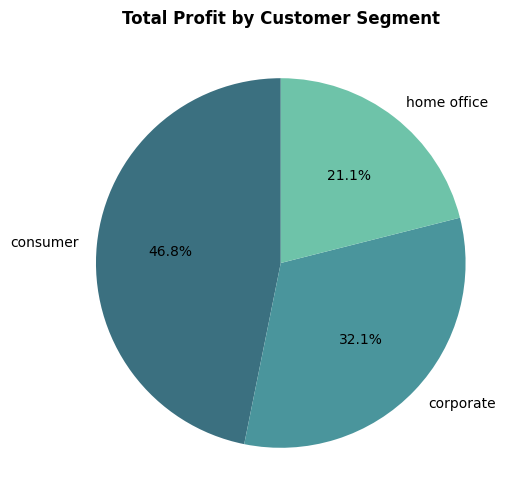

In [30]:
seg_counts = df.groupby("segment", observed=True)["profit"].sum()
colors = ['#3b7080', '#4a959c', '#6ec3a9']

plt.figure(figsize=(6, 6))
plt.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Total Profit by Customer Segment", weight="bold")
plt.show()

*Analytical Breakdown:*

**Consumer Segment**: Despite driving over half of all sales (50.6%), its profit share **drops** slightly to 46.8%, indicating slightly lower overall profit margins or heavier discount rates.

**Corporate & Home Office**: Both segments capture a higher share of profit (32.1% and 21.1%) relative to their sales shares (30.7% and 18.7%), showing higher profit efficiency and margins compared to retail consumers.

🔢 **Shipping Duration by Ship Mode** | Column Chart

<Figure size 800x500 with 0 Axes>

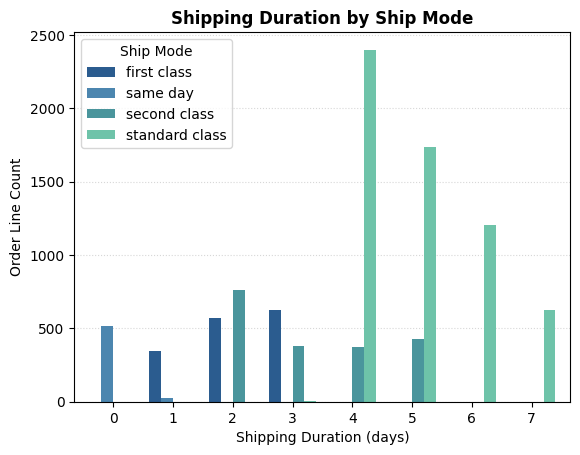

In [31]:
counts = pd.crosstab(df["shipping_duration"], df["ship_mode"])
colors = ['#2b5c8f', '#4c86af', '#4a959c', '#6ec3a9']

plt.figure(figsize=(8, 5))
counts.plot(kind="bar", color=colors, width=0.8, edgecolor="none")

plt.title("Shipping Duration by Ship Mode", weight="bold")
plt.xlabel("Shipping Duration (days)")
plt.ylabel("Order Line Count")
plt.legend(title="Ship Mode")
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xticks(rotation=0)

plt.show()

**Same Day**: From 0 to 1 days , **First Class**: From 1 to 3 days , **Second Class**: From 2 to 5 days while **Standard Class**: From 4 to 7 days (handling the highest overall order count which is more than 2300).

🔢 **Distribution of Order Discounts** | Column Chart

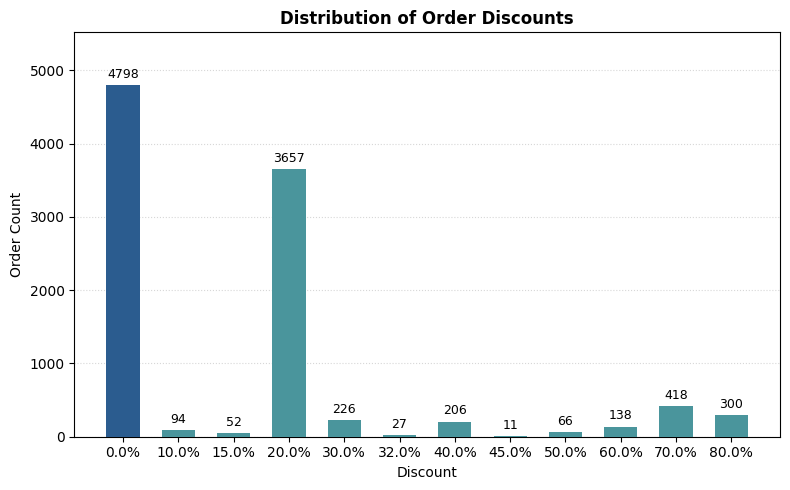

In [32]:
counts = (df["discount"] * 100).value_counts().sort_index()
colors = ["#2b5c8f" if v == counts.max() else "#4a959c" for v in counts.values]

plt.figure(figsize=(8, 5))

plt.grid(axis="y", linestyle=":", alpha=0.5)

bars = plt.bar(counts.index.astype(str) + "%", counts.values, color=colors, width=0.6, zorder=3)
plt.bar_label(bars, padding=3, fontsize=9)
plt.margins(y=0.15)

plt.title("Distribution of Order Discounts", weight="bold")
plt.xlabel("Discount")
plt.ylabel("Order Count")

plt.tight_layout()
plt.show()

High-Risk Deep Discounting Tail (50%–80%):Aggressive discount levels ($\ge 50\%$) account for 922 orders (~9.5% of volume), with noticeable spikes at 70.0% (418 orders) and 80.0% (300 orders).In standard retail datasets, discounts $\ge 50\%$ frequently generate negative profit margins (clearance/liquidation losses).

🔢 **Sales Distribution by Segment and Region** | Grouped Bar Chart

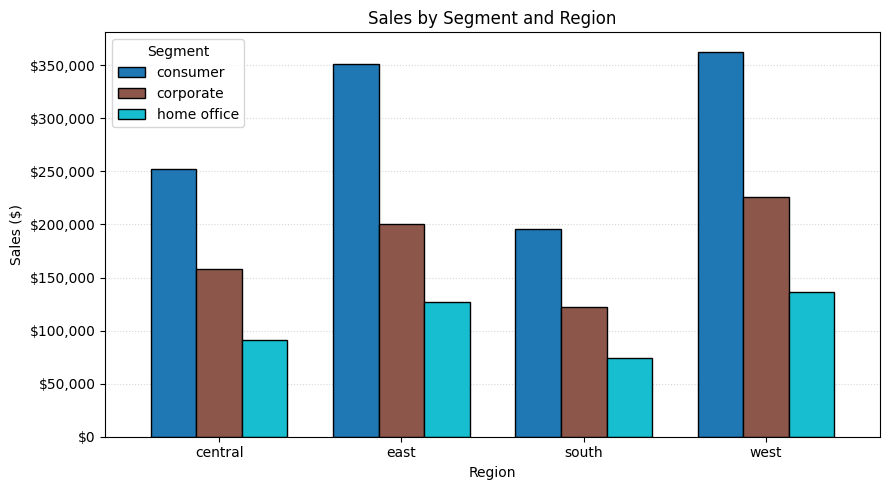

In [33]:
seg_reg = df.pivot_table(index="region", columns="segment", values="sales", aggfunc="sum")
fig, ax = plt.subplots(figsize=(9, 5))
seg_reg.plot(kind="bar", ax=ax, colormap="tab10", width=0.75, edgecolor="black")

ax.set(title="Sales by Segment and Region", xlabel="Region", ylabel="Sales ($)")
ax.yaxis.set_major_formatter("${x:,.0f}")
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=0)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

🔢 **Sales vs. Profit by Sub-Category** | Scatter Plot

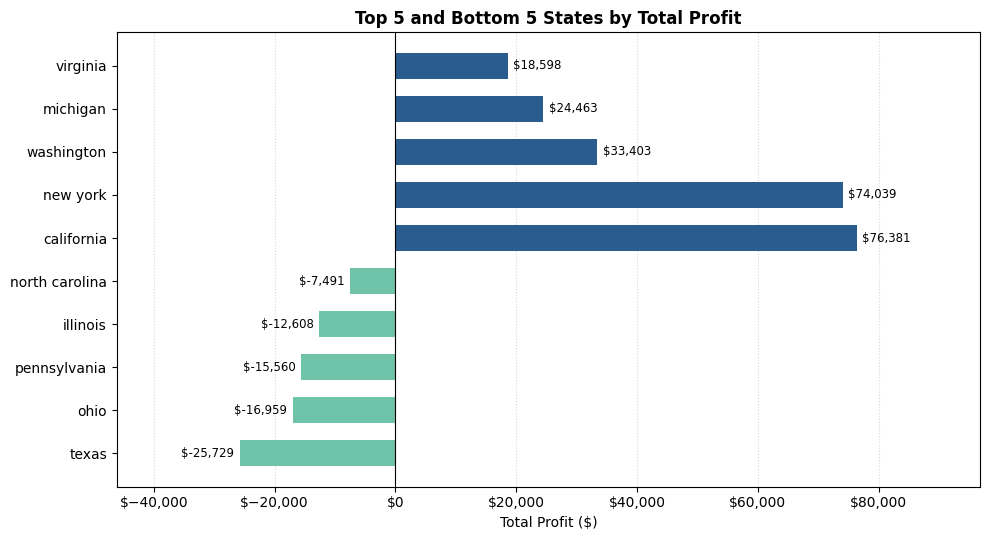

In [34]:
state_profit = df.groupby("state")["profit"].sum()
top_states = state_profit.nlargest(5)
bottom_states = state_profit.nsmallest(5).sort_values()
combined = pd.concat([bottom_states, top_states])

colors = ["#6ec3a9" if p < 0 else "#2b5c8f" for p in combined.values]

plt.figure(figsize=(10, 5.5))

bars = plt.barh(combined.index, combined.values, color=colors, height=0.6)

plt.axvline(0, color="black", linewidth=0.8)
plt.bar_label(bars, fmt="${:,.0f}", padding=4, fontsize=8.5)

plt.gca().xaxis.set_major_formatter("${x:,.0f}")
plt.margins(x=0.2)
plt.title("Top 5 and Bottom 5 States by Total Profit", weight="bold")
plt.xlabel("Total Profit ($)")
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

🔢 **Average Discounts in Top Loss-Making States** | Horizontal Bar Chart

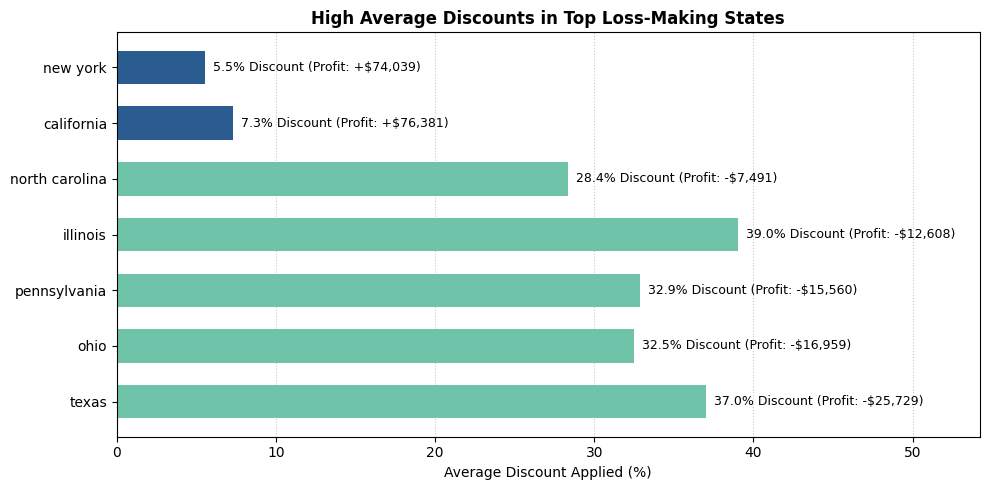

In [35]:
loss_states = ["texas", "ohio", "pennsylvania", "illinois", "north carolina"]
benchmark_states = ["california", "new york"]
selected_states = loss_states + benchmark_states

state_analysis = (
    df[df["state"].str.lower().isin(selected_states)]
    .groupby("state")
    .agg(avg_discount=("discount", "mean"), total_profit=("profit", "sum"))
    .loc[selected_states]
    .reset_index()
)

state_analysis["avg_discount"] *= 100

colors = [
    "#6ec3a9" if s in loss_states else "#2b5c8f"
    for s in state_analysis["state"]
]

labels = [
    f"{d:.1f}% Discount (Profit: -${abs(p):,.0f})"
    if p < 0
    else f"{d:.1f}% Discount (Profit: +${p:,.0f})"
    for d, p in zip(
        state_analysis["avg_discount"], state_analysis["total_profit"]
    )
]

plt.figure(figsize=(10, 5))

bars = plt.barh(
    state_analysis["state"],
    state_analysis["avg_discount"],
    color=colors,
    height=0.6,
)

plt.bar_label(bars, labels=labels, padding=6, fontsize=9)

plt.title(
    "High Average Discounts in Top Loss-Making States",
    weight="bold",
    fontsize=12,
)
plt.xlabel("Average Discount Applied (%)")
plt.margins(x=0.39)
plt.grid(axis="x", linestyle=":", alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()